# Global Cancer data Analysis

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy.stats import pearsonr, spearmanr, shapiro, f_oneway, kruskal

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [15]:
data= pd.read_csv('/Users/mrsahoo/Desktop/Project/Global_Cancer_EDA/global_cancer_patients_2015_2024.csv')

In [16]:
# Data overview
data.sample(5)

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
1737,PT0001737,38,Other,Australia,2021,7.1,5.3,0.4,6.9,2.4,Lung,Stage I,13897.27,3.3,5.62
28152,PT0028152,79,Other,Russia,2021,9.9,1.5,1.6,6.8,0.2,Breast,Stage III,52182.22,5.6,4.78
4499,PT0004499,66,Female,Germany,2016,9.8,5.2,3.6,4.1,8.8,Liver,Stage I,24126.08,1.9,6.50
24033,PT0024033,51,Male,Russia,2022,9.0,2.6,6.8,1.9,9.6,Prostate,Stage 0,15314.06,0.2,6.24
18569,PT0018569,48,Other,China,2017,4.5,8.6,3.2,6.8,1.9,Skin,Stage II,80473.81,9.7,4.61


In [17]:
# converting all column names to lowercase
data.columns= [i.lower() for i in data.columns]

In [18]:
# Information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             50000 non-null  object 
 1   age                    50000 non-null  int64  
 2   gender                 50000 non-null  object 
 3   country_region         50000 non-null  object 
 4   year                   50000 non-null  int64  
 5   genetic_risk           50000 non-null  float64
 6   air_pollution          50000 non-null  float64
 7   alcohol_use            50000 non-null  float64
 8   smoking                50000 non-null  float64
 9   obesity_level          50000 non-null  float64
 10  cancer_type            50000 non-null  object 
 11  cancer_stage           50000 non-null  object 
 12  treatment_cost_usd     50000 non-null  float64
 13  survival_years         50000 non-null  float64
 14  target_severity_score  50000 non-null  float64
dtypes:

In [19]:
# Checking Duplicate Values
data.duplicated().sum()

np.int64(0)

# Descriptive Analysis

In [7]:
data['age'].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: age, dtype: float64

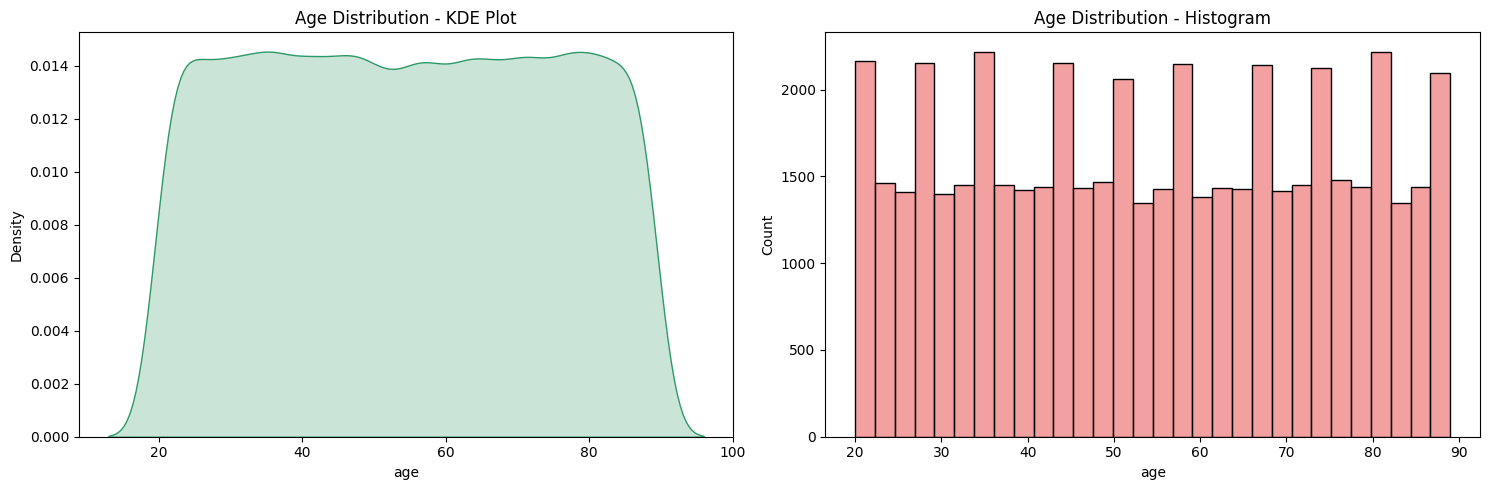

In [8]:
# Plotting for age column
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.kdeplot(data['age'], fill= True, color='#2D9966')
plt.title('Age Distribution - KDE Plot')

plt.subplot(1,2,2)
sns.histplot(data['age'], bins= 30, color= 'LightCoral')
plt.title('Age Distribution - Histogram')

plt.tight_layout()

# Inference:

-> Cancer incidence is concentrated in middle-aged and older adults, with a mean and median age of ~54 years, indicating higher prevalence after age 40.

-> Age distribution is broad and fairly uniform across adulthood (20–89 years), suggesting minimal sampling bias and good representation of different age       groups.

-> Half of the patients fall between 37 and 72 years, highlighting a significant elderly population, which is a known high-risk group for cancer.

-> High age variability (SD ≈ 20 years) indicates that age is a strong differentiating factor and should be analyzed in age bands for better insights.

-> No extreme age outliers are observed, implying clean and reliable age data suitable for downstream modeling and subgroup analysis.


In [9]:
# Gender column
data['gender'].value_counts()

gender
Male      16796
Female    16709
Other     16495
Name: count, dtype: int64

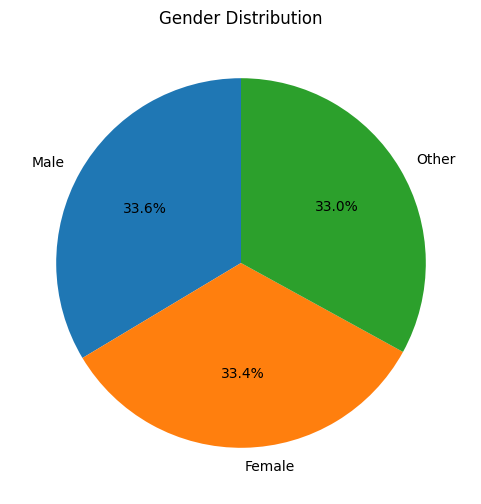

In [10]:
plt.figure(figsize=(6,6))   

data['gender'].value_counts().plot(
    kind='pie',
    autopct='%.1f%%',
    startangle=90
)
plt.ylabel('')
plt.title('Gender Distribution')
plt.show()

# Inference:
-> Data set contains 3 gender categories (Male, Female, Others) with the most common being male (16,796 records).
Gender distribution is sufficient for evaluating gender-specific survival trends and severity outcomes.

In [11]:
# Contry column
data['country_region'].value_counts().sort_values(ascending= True)

country_region
Canada       4864
China        4913
Pakistan     4926
Brazil       5004
Russia       5017
Germany      5024
India        5040
UK           5060
USA          5060
Australia    5092
Name: count, dtype: int64

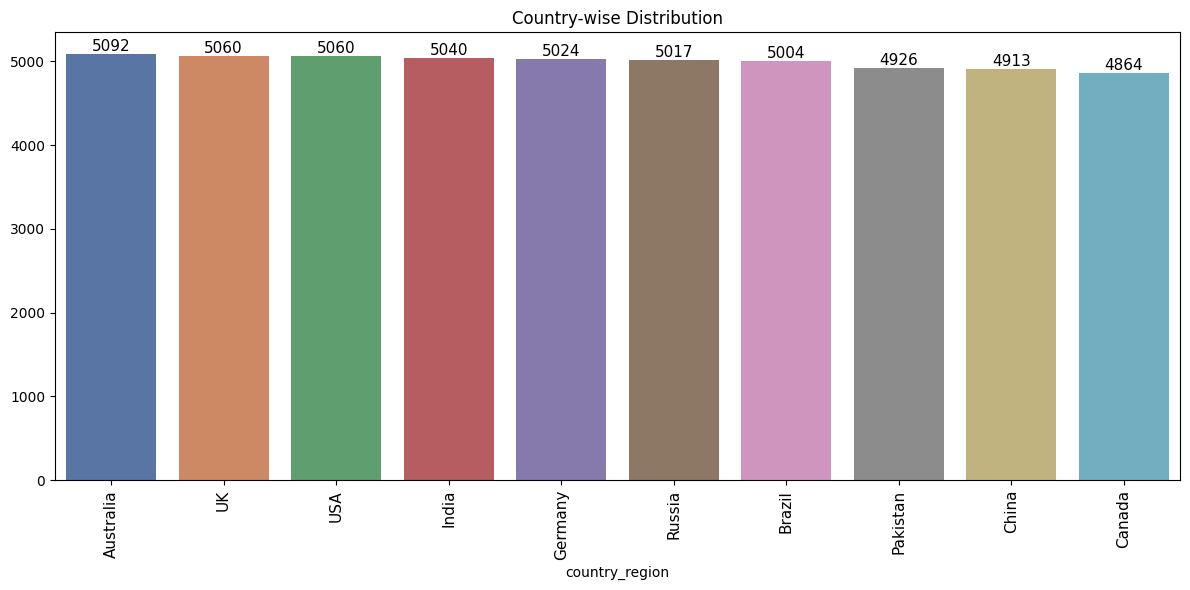

In [12]:
counts = data['country_region'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=counts.index,
    y=counts.values,
    palette='deep'
)

plt.xticks(rotation=90, fontsize=11)
plt.title('Country-wise Distribution')

# Add data labels
for i, v in enumerate(counts.values):
    plt.text(i, v, v, ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Inference:
-> Patient comes from 10 different countries, with Australia being the most represented (5092 patients). Number of data points for each country is almost same.

-> This diversity enables cross-country comparision of cancer outcomes and treatment economic.

In [13]:
# Cancer Type column
cnt= data['cancer_type'].value_counts()
cnt

cancer_type
Colon       6376
Prostate    6308
Leukemia    6266
Liver       6249
Skin        6231
Cervical    6222
Breast      6189
Lung        6159
Name: count, dtype: int64

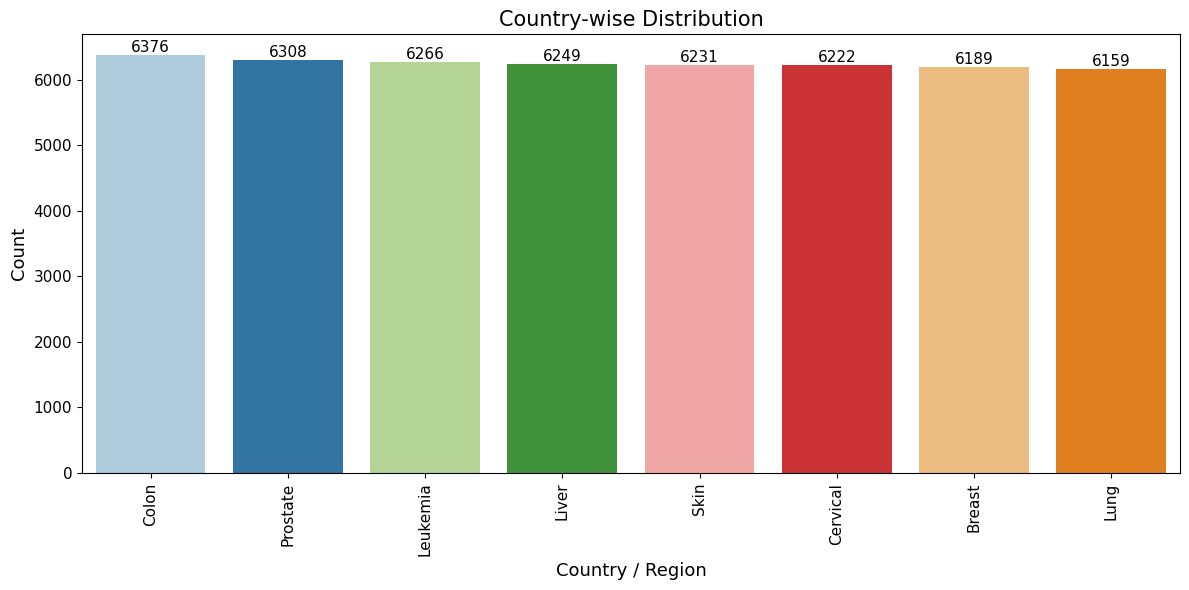

In [14]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=cnt.index,
    y=cnt.values,
    palette='Paired'
)

plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Country / Region', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.title('Country-wise Distribution', fontsize=15)

# Add data labels
for i, v in enumerate(cnt.values):
    ax.text(i, v, v, ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Inferences:
-> Cancer cases are fairly evenly distributed across cancer types, with counts ranging narrowly from ~6,150 to ~6,380, indicating no single dominant cancer type in the dataset.

-> Colon and Prostate cancers have the highest case counts, suggesting slightly higher representation or sampling frequency compared to other cancer types.

-> Lung and Breast cancers show comparatively lower counts, though the difference is marginal, implying balanced dataset construction rather than real-world prevalence.

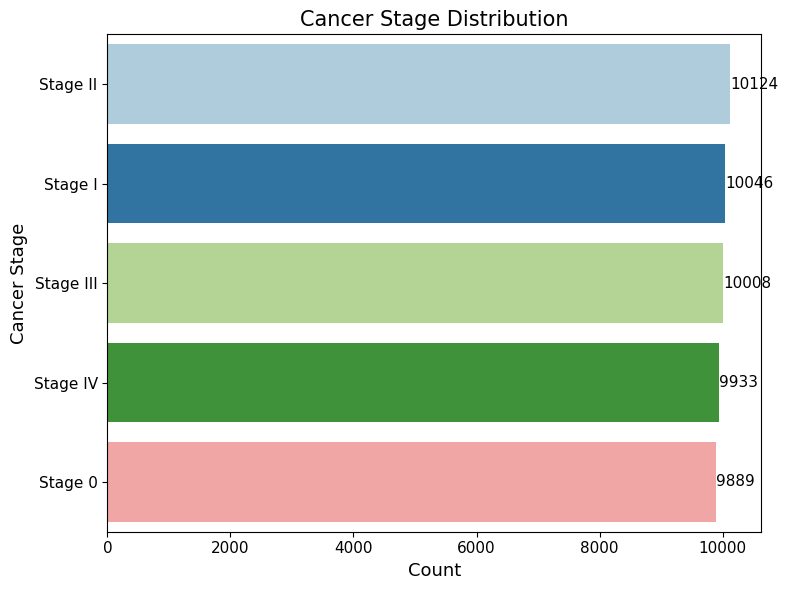

In [15]:
# Cancer Stage column

stages = data['cancer_stage'].value_counts()

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x=stages.values,
    y=stages.index,
    palette='Paired'
)

# Correct labels & title
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Count', fontsize=13)
plt.ylabel('Cancer Stage', fontsize=13)
plt.title('Cancer Stage Distribution', fontsize=15)

# Add data labels (horizontal logic)
for i, v in enumerate(stages.values):
    ax.text(v, i, v, va='center', fontsize=11)

plt.tight_layout()
plt.show()

# Inferences:

-> Cancer cases are almost evenly distributed across all stages (Stage 0–IV), with each stage having approximately 10,000 patients.

-> Slightly higher value is observed in Stage II and Stage I, suggesting marginally more diagnoses at early to mid stages, which enables meaningful stage-wise comparative analysis (e.g., treatment outcomes or survival rates).

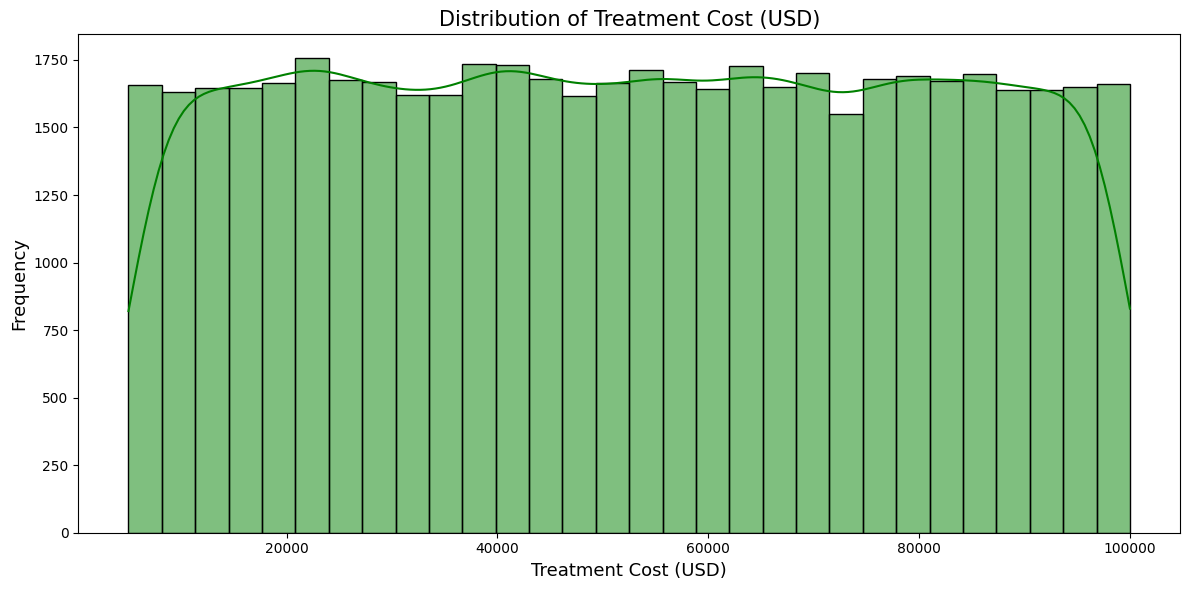

In [16]:
# Treatment Cost column
plt.figure(figsize=(12, 6))

sns.histplot(
    data['treatment_cost_usd'],
    bins=30,
    kde=True,
    color='green'
)

plt.title('Distribution of Treatment Cost (USD)', fontsize=15)
plt.xlabel('Treatment Cost (USD)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

plt.tight_layout()
plt.show()

In [17]:
data['treatment_cost_usd'].describe()

count    50000.000000
mean     52467.298239
std      27363.229379
min       5000.050000
25%      28686.225000
50%      52474.310000
75%      76232.720000
max      99999.840000
Name: treatment_cost_usd, dtype: float64

# Inferences:
-> Treatment cost (USD) has now skewness.

In [18]:
# Analysing the risk factors

risk_factors=['genetic_risk', 'air_pollution','alcohol_use','smoking','obesity_level']
summary= data[risk_factors].agg(['mean','std','min','max']).round(1)
summary

,genetic_risk,air_pollution,alcohol_use,smoking,obesity_level
mean,5.0,5.0,5.0,5.0,5.0
std,2.9,2.9,2.9,2.9,2.9
min,0.0,0.0,0.0,0.0,0.0
max,10.0,10.0,10.0,10.0,10.0


# Inferences:

-> These variables have nearly identical mean and standard deviations, indicating they were likely designed on the same standardized scale. They 
are essential in studying interaction effect.

# Determine the relationship between risk factors and cancer severity

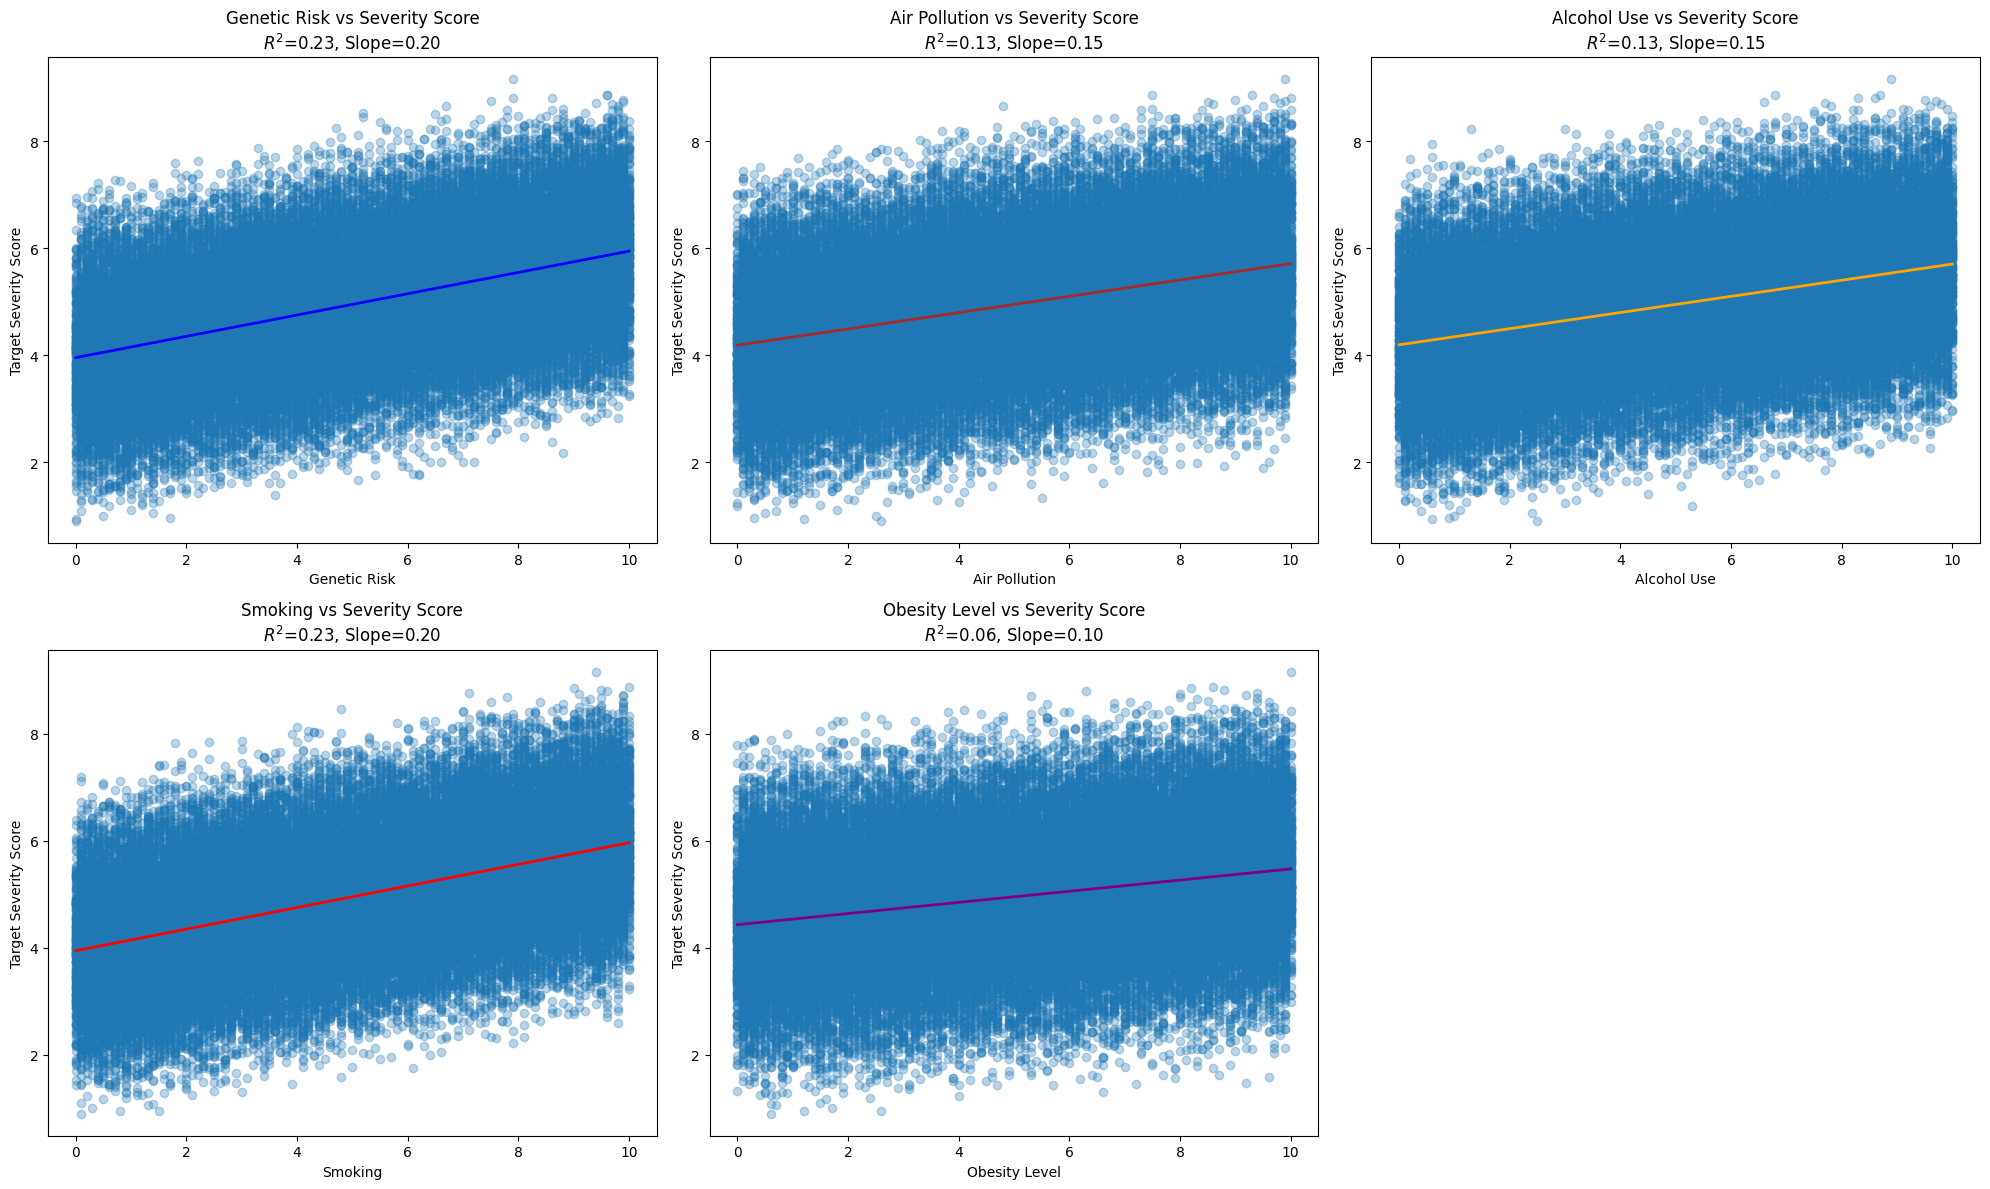

In [37]:
risk_factors= ['genetic_risk', 'air_pollution','alcohol_use','smoking','obesity_level']
titles= ['Genetic Risk','Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity Level']
colors= ["blue", "brown", "orange", "red", "purple"]

plt.figure(figsize=(20, 12))

for i, (factor, title, color) in enumerate(zip(risk_factors, titles, colors), 1):
    plt.subplot(2, 3, i)

    x = data[factor]
    y = data["target_severity_score"]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r_squared = r_value ** 2

    sns.regplot(
        x=factor,
        y="target_severity_score",
        data=data,
        scatter_kws={'alpha': 0.3},
        line_kws={'color': color, 'linewidth': 2}
    )

    plt.title(
        f"{title} vs Severity Score\n$R^2$={r_squared:.2f}, Slope={slope:.2f}",
        fontsize=12
    )
    plt.xlabel(title)
    plt.ylabel("Target Severity Score")


plt.tight_layout()
plt.show()


To understand the contribution of various risk factors to cancer severity, line plots were generated for five primary variables: Genetic Risk, Air Pollution, Alcohol Use, Smoking, and Obesity Level, plotted against the Target Severity Score.
All graphs reveal a positive relationship, indicating that as the level of a particular risk factor increases, the corresponding severity of the condition also tends to rise. However, the degree of association—measured by the slope and tightness of the confidence interval—varies across factors.

Genetic Risk vs Target Severity Score:

R² = 0.23:
A weak linear relationship. Only 23% of the variability in Target_Severity_Score can be explained by Genetic_Risk. This suggests that other factors likely play a larger role in influencing the severity score.
Slope = 0.20:
A positive slope indicates that as Genetic_Risk increases, the Target_Severity_Score also tends to increase. For each unit increase in Genetic_Risk, the target severity score increases by 0.20 units. However, because the R² is relatively low.

Air Pollution vs Target Severity Score:
R² = 0.13:
A very weak relationship. Only 13% of the variance in Target_Severity_Score can be explained by Air_Pollution, meaning that this factor has a limited effect on the target variable.
Slope = 0.15:
A positive slope means that as air pollution increases, the severity score slightly increases. But, due to the low R², this relationship is weak and unreliable as a predictor for the target severity.

Alcohol Use vs Target Severity Score:

R² = 0.13:
Similarly, the relationship between Alcohol_Use and Target_Severity_Score is also weak. Only 13% of the variation in the target score is explained by alcohol use.
Slope = 0.15:
The positive slope indicates that increased alcohol use correlates with a slight increase in target severity. However, like air pollution, the weak R² suggests other factors have a much stronger influence on the target.

Smoking vs Target Severity Score:

R² = 0.23:
A weak relationship, similar to Genetic_Risk. Smoking explains only 23% of the variance in the target score, leaving the majority of the variation to be explained by other factors.
Slope = 0.20:
The positive slope implies that as smoking increases, the target severity score increases as well. This relationship is similar to that of genetic risk, but with a weak linear association (low R²).

Obesity Level vs Target Severity Score:

R² = 0.06:
The weakest relationship among all factors. Only 6% of the variation in the target score is explained by obesity level, suggesting that obesity has a minimal effect on the target variable.
Slope = 0.10:
A positive slope, indicating a slight increase in the severity score as obesity level increases. However, due to the very low R², this is a weak and unreliable relationship.

Key Takeaways:

Weak Linear Relationships:
The R² values for all risk factors are relatively low, ranging from 0.06 to 0.23. This indicates that while there is some relationship between these risk factors and the Target_Severity_Score, it is weak. These factors alone do not explain much of the variation in the target variable.

Positive Trends:

All the slope values are positive, suggesting that as each risk factor increases, the Target_Severity_Score tends to increase as well. However, because the R² values are low, this increase is not strongly consistent across all data points.

Other Influences:

The low R² values imply that other, unmeasured factors are likely contributing to the variation in Target_Severity_Score. The risk factors you examined are only weakly correlated with the target and are not reliable predictors on their own.

Next Steps:

Given the weak explanatory power of these individual factors, it might be useful to explore other variables or more complex models that could account for more of the variation in the Target_Severity_Score. This could include interactions between risk factors, adding new features, or applying more sophisticated regression techniques.

# Analyze the proportion of early-stage diagnoses by cancer type

In [42]:
types= data['cancer_type'].unique()

df= []

for i in types:
    stage_count= data[data['cancer_type']== i]['cancer_stage'].value_counts()
    early_stage= stage_count.get('Stage 0') + stage_count.get('Stage I')
    proportion= ((early_stage/ len(data[data['cancer_type']== i]))*100).round(2)
    df.append({'cancer_type': i, 'proportion_%': proportion})

pd.DataFrame(df)

,cancer_type,proportion_%
0,Lung,38.43
1,Leukemia,39.53
2,Breast,39.47
3,Colon,40.42
4,Skin,40.41
5,Cervical,39.86
6,Prostate,40.19
7,Liver,40.61


# Identify key predictors of cancer severity and survival years.

In [66]:
features= ['age', 'genetic_risk', 'air_pollution', 'alcohol_use', 'smoking', 'obesity_level']

targets= ['target_severity_score', 'survival_years']

#calculate correlations
pearson_corr= data[features+targets].corr(method="pearson")
spearman_corr= data[features+targets].corr(method="spearman")

# slice out only thr relationship with target variables
pearson_results= pearson_corr[targets]
spearman_results=spearman_corr[targets]

#combine both
correlation_df= pd.concat([pearson_results,spearman_results], axis=1, keys=["Pearson","Spearman"])
correlation_df

Pearson                 \
                      target_severity_score survival_years   
age                               -0.001481      -0.000147   
genetic_risk                       0.478700       0.001708   
air_pollution                      0.366963       0.000893   
alcohol_use                        0.363250      -0.000527   
smoking                            0.484420       0.001371   
obesity_level                      0.251366       0.009771   
target_severity_score              1.000000       0.004161   
survival_years                     0.004161       1.000000   

                                   Spearman                 
                      target_severity_score survival_years  
age                               -0.002076      -0.000149  
genetic_risk                       0.472193       0.001684  
air_pollution                      0.357528       0.000841  
alcohol_use                        0.354694      -0.000543  
smoking                            0.477881       0.001372  
obesity_level                      0.243152       0.009780  
target_severity_score              1.000000       0.003431  
survival_years                     0.003431       1.000000

# Random forest for target severity score

In [89]:
# Converting categorical columns to numerical using Label Encoding

categorical_cols=  data.select_dtypes(include=['object']).columns[1:]

for col in categorical_cols:
    le= LabelEncoder()
    data[col]=le.fit_transform(data[col])

# preparing features and target variable
x= data.drop(columns=['patient_id','survival_years','target_severity_score','treatment_cost_usd'])
y= data['target_severity_score' ]

# splitting the data
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42 )

#training model
model= RandomForestRegressor(n_estimators= 200, max_depth= None, min_samples_split= 2, min_samples_leaf=1, random_state=40)
model.fit(x_train, y_train)

#evaluate the model:
train_r2_score= r2_score(y_train, model.predict(x_train))
test_r2_score= r2_score(y_test, model.predict(x_test))

print(train_r2_score)
print(test_r2_score)

0.9689965882264893
0.7679226572153739


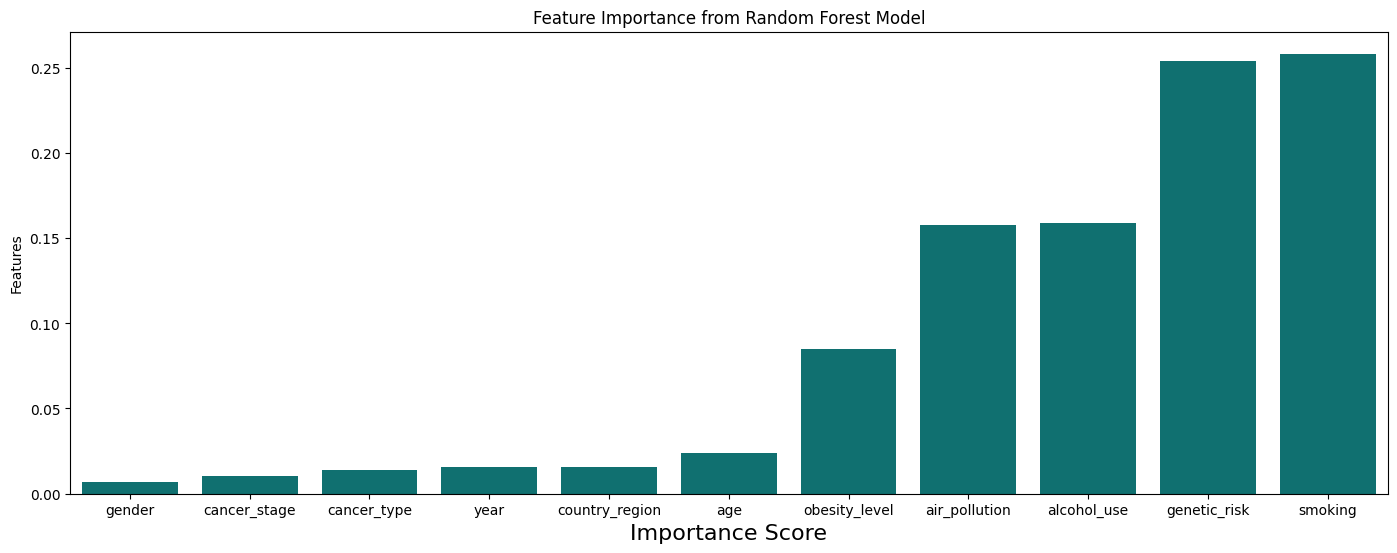

In [99]:
feature_importance= pd.Series(model.feature_importances_, index=x.columns).sort_values(ascending= True)

# plotting feature importance
plt.figure(figsize=(17,6))
sns.barplot(y= feature_importance.values, x= feature_importance.index, color='teal' )
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance Score', fontsize=16)
plt.ylabel('Features')
plt.show()

Feature	Importance	Interpretation
Smoking	0.2336	Most important predictor of severity score. The more a patient smokes, the higher their severity tends to be.
Genetic_Risk	0.2286	Strong genetic predisposition is nearly as important as smoking.
Treatment_Cost_USD	0.2133	Higher treatment costs are associated with more severe conditions.
Alcohol_Use	0.1291	Alcohol also plays a significant role.
Air_Pollution	0.1271	Environmental factor—patients in more polluted areas have worse severity scores.
Obesity_Level	0.0573	Has an effect, but much smaller.
Age to Gender	< 0.01	Very low importance; these don’t explain much variation in severity score.


E.g., Smoking, Genetic Risk, AIr plollution are major influencers. This tells you where interventions might reduce severity.

In [11]:
from sklearn.model_selection import GridSearchCV


categorical_cols = ["gender", "country_region", "cancer_type", "cancer_stage"]

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# Prepare features and target

X = data.drop(columns=["patient_id","survival_years","target_severity_score","treatment_cost_usd"])

y_severity = data["survival_years"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y_severity,test_size=0.2,random_state=40)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search with Random Forest
rf = RandomForestRegressor(random_state=40)

gscv = GridSearchCV(rf, param_grid, cv=3, scoring="r2", n_jobs=-1)

gscv.fit(X_train, y_train)

best_rf_severity = gscv.best_estimator_


# Model Evaluation
train_r2 = r2_score(y_train, best_rf_severity.predict(X_train))
test_r2 = r2_score(y_test, best_rf_severity.predict(X_test))

print("Best Parameters:", gscv.best_params_)
print("Train R² Score:", round(train_r2, 3))
print("Test R² Score :", round(test_r2, 3))

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Train R² Score: 0.009
Test R² Score : -0.0


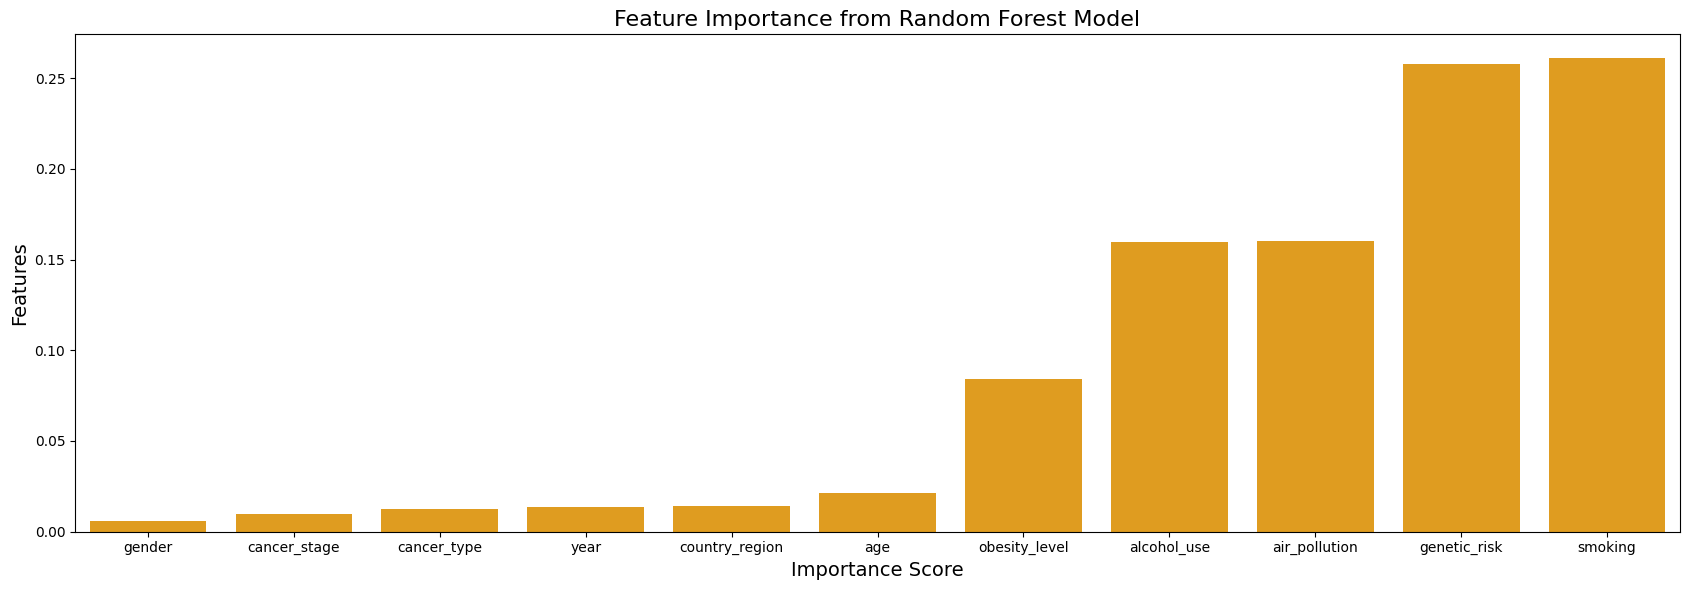

In [10]:
feature_importance = pd.Series(best_rf_severity.feature_importances_, index=X.columns).sort_values(ascending=True)

# Plot feature importance (horizontal bar chart)
plt.figure(figsize=(17, 6))

sns.barplot(y=feature_importance.values, x=feature_importance.index, color='orange')

plt.title('Feature Importance from Random Forest Model', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)

plt.tight_layout()
plt.show()

# Explore the economic burden of cancer treatment across different demographics and countries

In [2]:
df= pd.read_csv('/Users/mrsahoo/Desktop/Project/Global_Cancer_EDA/global_cancer_patients_2015_2024.csv')

Text(0.5, 1.0, 'Average Treatment Cost by Country')

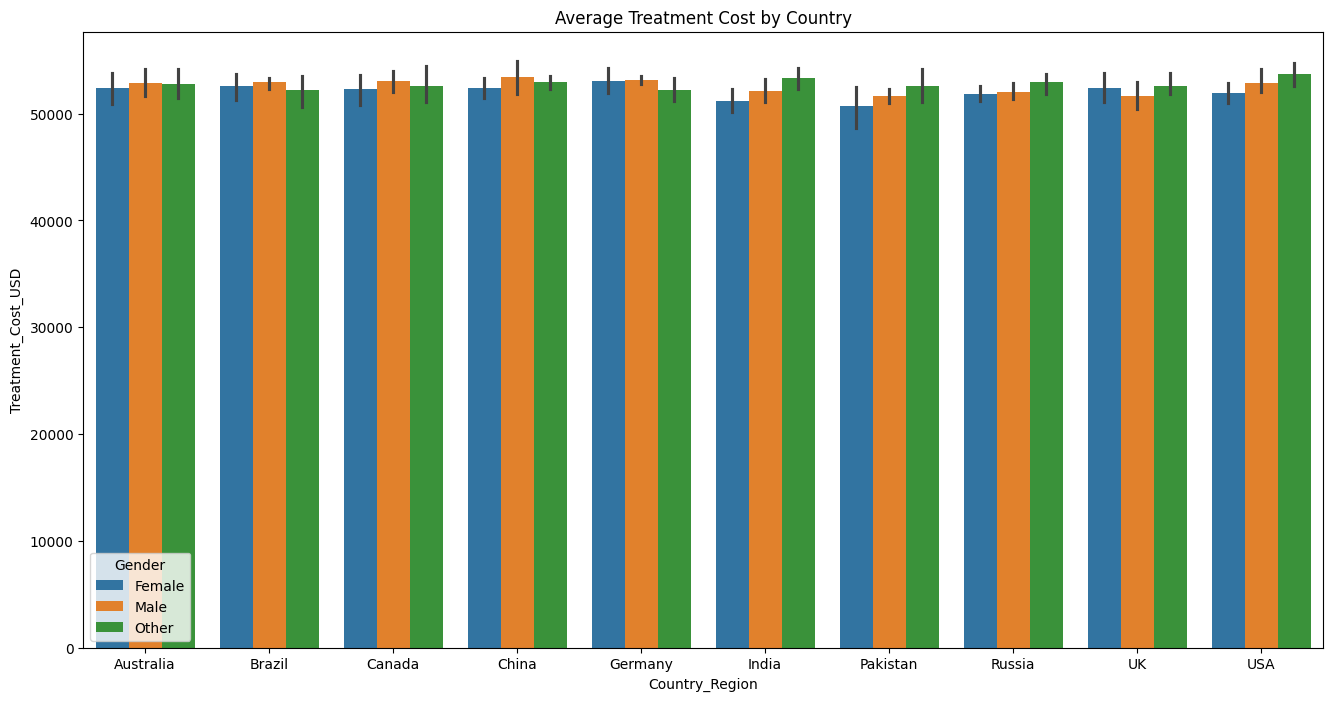

In [3]:
df["Age_Group"]=pd.cut(df["Age"],bins=[0,30,45,60,75,100],labels=["0-30","31-45","46-60","61-75","76+"])

country_age_cost= df.groupby(['Country_Region','Age_Group','Gender'])['Treatment_Cost_USD'].mean().reset_index()

plt.figure(figsize=(16,8))
sns.barplot(data= country_age_cost, x='Country_Region', y='Treatment_Cost_USD', hue='Gender')
plt.title('Average Treatment Cost by Country')

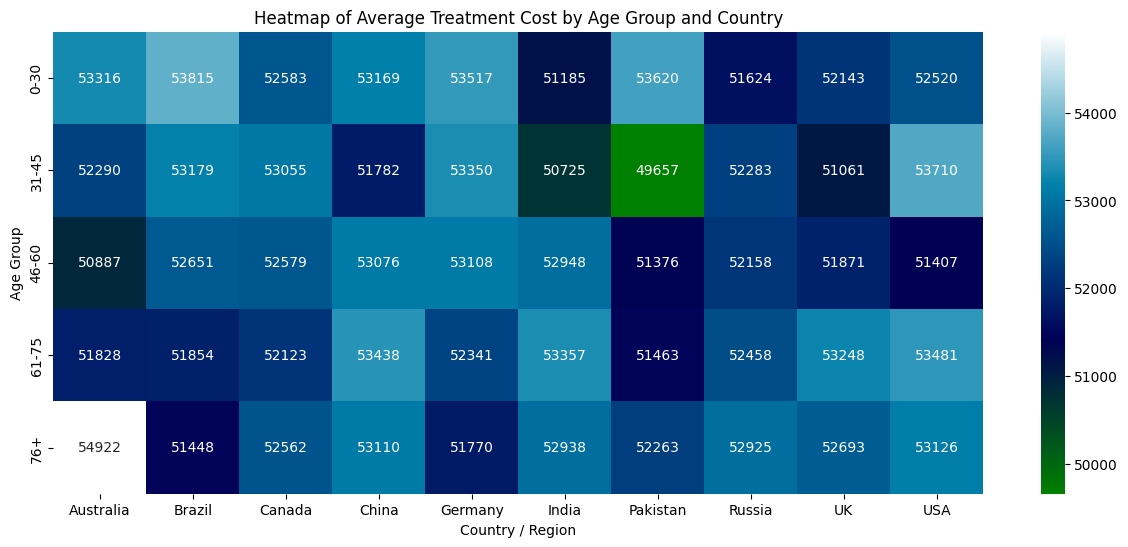

In [12]:
country_cost= df.groupby(['Country_Region','Age_Group'])['Treatment_Cost_USD'].mean().reset_index()
hitmap_data= country_cost.pivot(index='Age_Group', columns= 'Country_Region', values='Treatment_Cost_USD')

plt.figure(figsize=(15,6))
sns.heatmap(hitmap_data, annot=True, fmt=".0f", cmap='ocean')
plt.title('Heatmap of Average Treatment Cost by Age Group and Country')
plt.xlabel('Country / Region')
plt.ylabel('Age Group')
plt.show()

Geographic Disparities in Economic Burden Cancer treatment costs are significantly higher in developed nations such as the USA, Australia, and China, revealing the heavy financial load in advanced healthcare systems. Meanwhile, countries like India and Pakistan exhibit comparatively lower costs, likely due to lower healthcare pricing structures or limited access to advanced treatment. This highlights a clear global inequality in healthcare affordability that can intensify financial strain depending on a patient’s country of residence.

Gender-Based Cost Patterns Are Uniform Across all countries, gender-based differences in average treatment costs are minimal, suggesting no major gender bias in pricing or access to cancer care. This uniformity may reflect standardization in treatment protocols or equitable healthcare policies, but it also points to the fact that the financial impact of cancer is universal across genders.

Age-Related Escalation in Treatment Costs Treatment costs tend to rise with age, particularly for those aged 61 and above. This trend is especially evident in countries like Australia and the USA, where older age groups face sharply higher costs. The increased financial burden in these groups could be due to more intensive care needs, multiple comorbidities, or prolonged treatments. This pattern underlines the vulnerability of elderly populations and the pressing need for targeted support for senior citizens.

Role of Healthcare Systems in Cost Variation Countries with robust public healthcare systems—such as Canada, Germany, and the UK—show relatively stable treatment costs across age groups, reflecting the benefits of healthcare subsidies or coverage. This consistency reinforces the importance of government intervention and universal healthcare in mitigating financial disparities in cancer treatment.

# Assess whether higher treatment cost is associated with longer survival


In [30]:
x= data['treatment_cost_usd']
y= data['survival_years']

# Performing Pearson correlation test
pearson_corr, pearson_p= pearsonr(x,y)
print(f'Pearson correlation Cofficient: {pearson_corr}')
print(f'P-value: {pearson_p}')

print("-" *50)

# Performing spearman correlation test
spearman_corr, spearman_p= spearmanr(x,y)
print(f'spearman correlation Cofficient: {spearman_corr}')
print(f'P-value: {spearman_p}')


Pearson correlation Cofficient: -0.00042940542830214624
P-value: 0.9235082012963307
--------------------------------------------------
spearman correlation Cofficient: -0.0004454737292549569
P-value: 0.9206551702014918


In [33]:
# Hypotheses testing
Null_hypothesis= 'There is no significant correlation between Treatment Cost and Survival Years.'
Alternative_hypothesis= 'There is a significant correlation between Treatment Cost and Survival Years.'

alpha=0.05
def interpret_corr(corr, p, method):
    if p < alpha:
        print(f'{method} correlation is statistically significant with correlation coefficient: {corr} and p-value: {p}')
    else:
        print(f'{method} correlation is not statistically significant with correlation coefficient: {corr} and p-value: {p}')

interpret_corr(pearson_corr, pearson_p, 'Pearson')
interpret_corr(spearman_corr, spearman_p, 'Spearman')


Pearson correlation is not statistically significant with correlation coefficient: -0.00042940542830214624 and p-value: 0.9235082012963307
Spearman correlation is not statistically significant with correlation coefficient: -0.0004454737292549569 and p-value: 0.9206551702014918


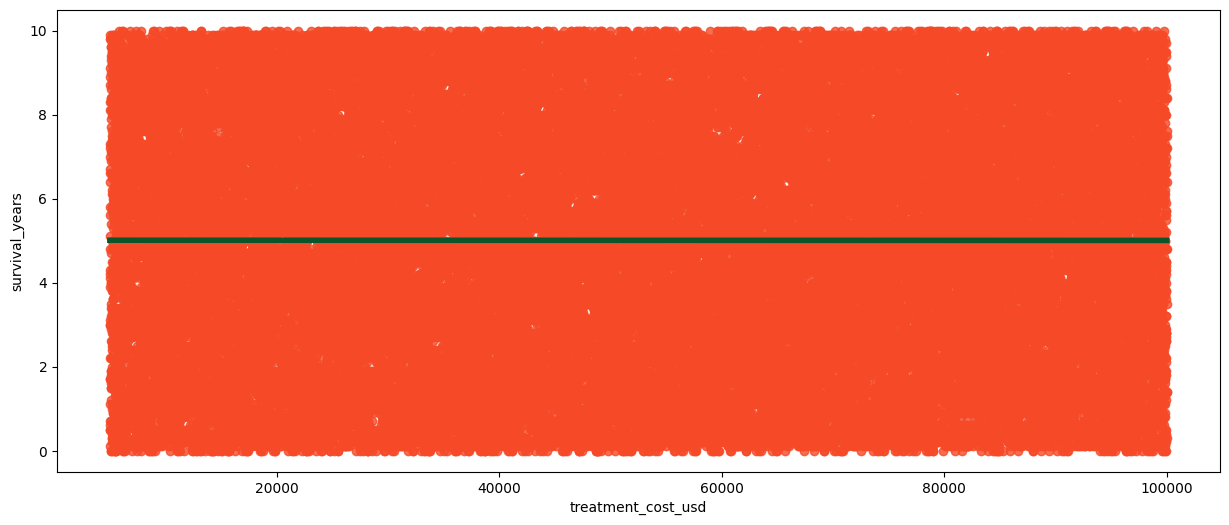

In [43]:
plt.figure(figsize=(15,6))

sns.regplot(x= x, y= y, color='#F54927', line_kws={"linewidth":4, 'color':'#0D542B'})
plt.show()

There is no relation between Treatment Cost and Survival years

# Evaluate if higher cancer stages lead to greater treatment costs and reduced survival years

In [68]:
df=data.copy()

group_stats= df.groupby('cancer_stage')[['treatment_cost_usd','survival_years']]. mean().reset_index()
group_stats

,cancer_stage,treatment_cost_usd,survival_years
0,Stage 0,52572.589493,5.015199
1,Stage I,52674.079638,5.012990
2,Stage II,52082.841258,4.995170
3,Stage III,52708.197506,5.036311
4,Stage IV,52302.471041,4.972596


In [ ]:
# Hypothesis Testing Conclusion
# Treatment Cost vs. Cancer Stage Null Hypothesis (H₀): The average treatment cost is the same across all cancer stages. 
#                                                       Alternative Hypothesis (H₁): At least one stage has a different average cost.

# Survival Years vs. Cancer Stage Null Hypothesis (H₀): The average survival years are the same across all cancer stages. 
#                                                       Alternative Hypothesis (H₁): At least one stage has a different survival duration.

stage_order= ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']

groupd_cost=[]
groupd_survival=[]

for i in stage_order:
    stage_data=df[df['cancer_stage'] == i]
    cost= stage_data['treatment_cost_usd']
    survival= stage_data['survival_years']
    groupd_cost.append(cost)
    groupd_survival.append(survival)

In [ ]:
# normality check
normal_cost=0
normal_survival=0

for i in range(len(stage_order)):
    cost_p= shapiro(groupd_cost[i]).pvalue
    survival_p= shapiro(groupd_survival[i]).pvalue 

    print(f'Cost:{cost_p} for group {i}')
    print(f'Survival:{survival_p} for group {i}')

    if cost_p < 0.05:
        normal_cost += 1
    if survival_p < 0.05:
        normal_survival += 1

print(normal_cost)
print(normal_survival)

Cost:1.5471821061637387e-47 for group 0
Survival:1.6291039522109283e-47 for group 0
Cost:7.306523956943449e-48 for group 1
Survival:7.575551046262835e-48 for group 1
Cost:8.943579643045432e-48 for group 2
Survival:4.041659465829021e-48 for group 2
Cost:5.267270033024548e-48 for group 3
Survival:1.3648520457950436e-47 for group 3
Cost:1.583864018957793e-47 for group 4
Survival:2.299259828983219e-47 for group 4
5
5


ANNOVA test can not be performed as the groups are not normaly distributed so wii do Kruskal-Wallis H test

In [64]:
kruskal_cost= kruskal(*groupd_cost)
kruskal_survival= kruskal(*groupd_survival)

p_cost= kruskal_cost.pvalue
p_survival= kruskal_survival.pvalue

print(f'Kruskal-Wallis Test P-value for Treatment Cost: {p_cost}')
print(f'Kruskal-Wallis Test P-value for Survival Rate: {p_survival}')

Kruskal-Wallis Test P-value for Treatment Cost: 0.4254451689062656
Kruskal-Wallis Test P-value for Survival Rate: 0.6033078729984223



=== Kruskal-Wallis Test: Treatment Cost across Cancer Stages ===

P-value: 0.4254
Conclusion: No significant difference in treatment costs among cancer stages.

=== Kruskal-Wallis Test: Survival Years across Cancer Stages ===

P-value: 0.6033
Conclusion: No significant difference in survival years among cancer stages.
=== Kruskal-Wallis Test: Treatment Cost across Cancer Stages ===

P-value: 0.4254 Conclusion: No significant difference in treatment costs among cancer stages.

=== Kruskal-Wallis Test: Survival Years across Cancer Stages ===

P-value: 0.6033 Conclusion: No significant difference in survival years among cancer stages.

# Examine whether higher genetic risk amplifies the negative effects of smoking on cancer severity

In [79]:
'''
Null Hypothesis (H₀): The interaction effect between genetic risk and smoking on cancer Severity is not significant. 
                       (Genetic risk does not amplify or alter the effect of smoking.)

Alternative Hypothesis (H₁): The interaction effect between genetic risk and smoking on cancer severity is significant. 
                            (Genetic risk does amplify or alter the effect of smoking.)
'''

import statsmodels.formula.api as sm
model= sm.ols('target_severity_score ~ genetic_risk * smoking', data= data).fit()
model.summary2().tables[1].loc['genetic_risk:smoking']

Coef.      -0.000228
Std.Err.    0.000471
t          -0.484187
P>|t|       0.628255
[0.025     -0.001150
0.975]      0.000694
Name: genetic_risk:smoking, dtype: float64

Interpretation:
The interaction coefficient is negative but very small: -0.000228

The p-value = 0.628, which is greater than 0.05, so we fail to reject the null hypothesis

🧪 Conclusion (Statistical):
✅ Test Used: Multiple Linear Regression with interaction term

📌 Null Hypothesis (H₀): No interaction effect between genetic risk and smoking

📌 Alternative Hypothesis (H₁): There is an interaction effect

The interaction effect between Genetic Risk and Smoking on Target Severity Score is not statistically significant (p = 0.628 > 0.05).

This means that based on your data, there is no evidence that Genetic Risk amplifies or reduces the effect of Smoking on the Target Severity Score.

In other words, smoking and genetic risk may each have independent effects (or none), but they do not interact in a way that significantly changes the outcome.